In [2]:
import pickle

# ── CONFIGURATION — adjust path to your directory structure ─────────────
PICKLE_FILE = '../data/pickle/pose_bisindo.pkl'

with open(PICKLE_FILE, 'rb') as f:
    data = pickle.load(f)

In [3]:
def simple_normalize(self, origin_input_data):
    conf = origin_input_data[:,:,6]
    origin_input_data = origin_input_data / self.norm_div - 1

    input_data = origin_input_data[:, :, 0:2]
    if self.norm_point is not None:
        index = 0
        for part in self.used_part:
            if index == 0:
                start, end = 0, self.split[0]
            else:
                start, end = self.split[index-1], self.split[index]
            if part == 'body':
                input_data[:, start:end] = (
                    input_data[:, start:end] - input_data[0,self.norm_point[index]:self.norm_point[index]+2].mean(0)[None,None]
                )
            elif part == 'hand21':
                input_data[:, start:end] = (
                    input_data[:, start:end] - input_data[:,self.norm_point[index]][:,None,:]
                )
                index += 1
                start, end = self.split[index-1], self.split[index]
                input_data[:, start:end] = (
                    input_data[:, start:end] - input_data[:,self.norm_point[index]][:,None,:]
                )
            else:
                input_data[:, start:end] = (
                    input_data[:, start:end] - input_data[:,self.norm_point[index]][:,None,:]
                )
            index += 1
    return torch.cat(
        [input_data, origin_input_data[:, :, 2:6], conf.unsqueeze(-1)], dim=-1
    )

In [ ]:
def simple_normalize(self, origin_input_data):
    conf = origin_input_data[:,:,6]
    # scale conversion (norm_div = 0.5)
    origin_input_data = origin_input_data / self.norm_div - 1

    input_data = origin_input_data[:, :, 0:2]
    if self.norm_point is not None:
        index = 0
        for part in self.used_part:
            if index == 0:
                start, end = 0, self.split[0]
            else:
                start, end = self.split[index-1], self.split[index]
            if part == 'body':
                input_data[:, start:end] = (
                    input_data[:, start:end] - input_data[0,self.norm_point[index]:self.norm_point[index]+2].mean(0)[None,None]
                )
            # wrist-centered normalization
            elif part == 'hand21':
                input_data[:, start:end] = (
                    input_data[:, start:end] - input_data[:,self.norm_point[index]][:,None,:]
                )
                index += 1
                start, end = self.split[index-1], self.split[index]
                input_data[:, start:end] = (
                    input_data[:, start:end] - input_data[:,self.norm_point[index]][:,None,:]
                )
            else:
                input_data[:, start:end] = (
                    input_data[:, start:end] - input_data[:,self.norm_point[index]][:,None,:]
                )
            index += 1
    return torch.cat(
        [input_data, origin_input_data[:, :, 2:6], conf.unsqueeze(-1)], dim=-1
    )

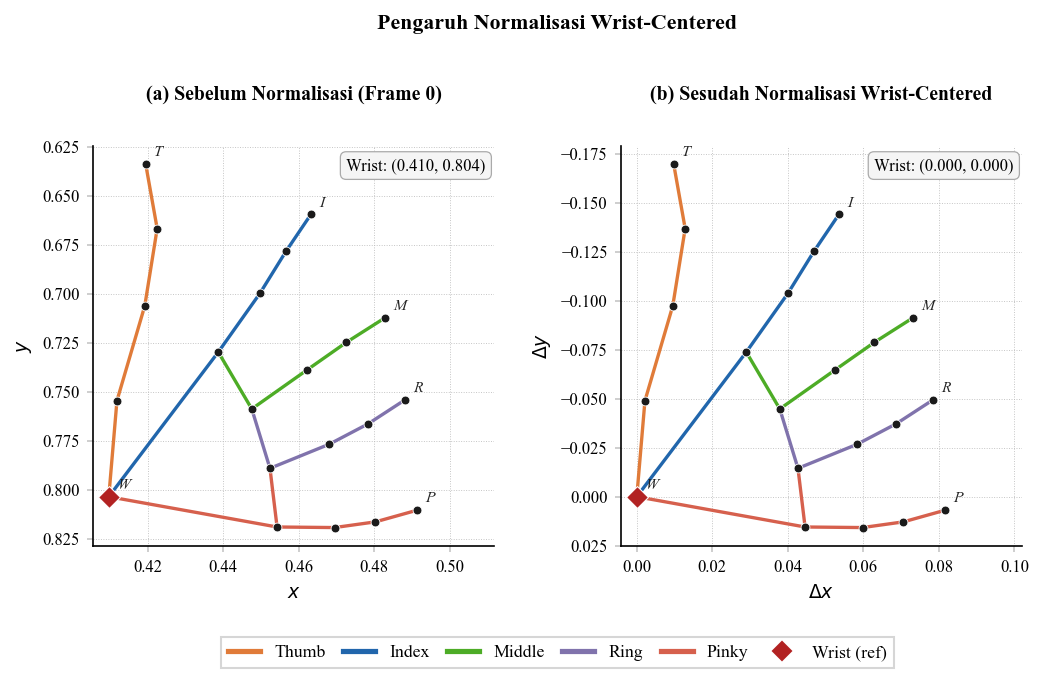

Saved: hand_normalization_q1.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

plt.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'DejaVu Serif'],
    'font.size':          10,
    'axes.labelsize':     9,
    'xtick.labelsize':    8,
    'ytick.labelsize':    8,
    'axes.linewidth':     0.8,
    'xtick.major.width':  0.6,
    'ytick.major.width':  0.6,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'figure.dpi':         150,
})

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(0,17),(17,18),(18,19),(19,20),
]

FINGER_COLORS = {
    'Thumb':  '#E07B39',
    'Index':  '#2166AC',
    'Middle': '#4DAC26',
    'Ring':   '#8073AC',
    'Pinky':  '#D6604D',
}

SEG_COLOR_MAP = {
    (0,1):'Thumb',(1,2):'Thumb',(2,3):'Thumb',(3,4):'Thumb',
    (0,5):'Index',(5,6):'Index',(6,7):'Index',(7,8):'Index',
    (5,9):'Middle',(9,10):'Middle',(10,11):'Middle',(11,12):'Middle',
    (9,13):'Ring',(13,14):'Ring',(14,15):'Ring',(15,16):'Ring',
    (13,17):'Pinky',(0,17):'Pinky',(17,18):'Pinky',(18,19):'Pinky',(19,20):'Pinky',
}

JOINT_LABELS = {0:'W', 4:'T', 8:'I', 12:'M', 16:'R', 20:'P'}


def plot_hand_q1(ax, points, xlabel, ylabel, annotation):
    for conn, finger in SEG_COLOR_MAP.items():
        s, e = conn
        ax.plot([points[s,0], points[e,0]],
                [points[s,1], points[e,1]],
                color=FINGER_COLORS[finger],
                linewidth=1.6, solid_capstyle='round',
                solid_joinstyle='round', zorder=3)

    ax.scatter(points[:,0], points[:,1],
               s=18, color='#1a1a1a', zorder=5,
               linewidths=0.4, edgecolors='white')

    ax.scatter(points[0,0], points[0,1],
               s=55, marker='D', color='#B22222',
               zorder=6, linewidths=0.5, edgecolors='white')

    for idx, lbl in JOINT_LABELS.items():
        ax.annotate(lbl,
                    xy=(points[idx,0], points[idx,1]),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=7.5, color='#222222', fontstyle='italic')

    # Annotation box: pojok kanan atas
    ax.text(0.98, 0.97, annotation,
            transform=ax.transAxes,
            fontsize=8, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='#F5F5F5',
                      edgecolor='#AAAAAA', linewidth=0.6))

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.invert_yaxis()
    # ax.set_aspect('equal')
    ax.set_box_aspect(1)
    # Panjangkan sumbu x ke kanan
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin, xmax + (xmax - xmin) * 0.18)
    ax.grid(True, linestyle=':', linewidth=0.45, color='#BBBBBB', alpha=0.9)
    ax.tick_params(length=3, width=0.18)


# ── Data ─────────────────────────────────────────────────────────────────────
sample_video_id = list(data.keys())[0]
video_keypoints = data[sample_video_id]['keypoints']

START_IDX, END_IDX = 21, 42
valid_frame_idx = -1
for i in range(len(video_keypoints)):
    if np.any(video_keypoints[i, START_IDX:END_IDX, :] != 0):
        valid_frame_idx = i
        break

data_sebelum = video_keypoints[valid_frame_idx, START_IDX:END_IDX, :]
data_sesudah = data_sebelum - data_sebelum[0]

wrist = data_sebelum[0]
ann_before = f"Wrist: ({wrist[0]:.3f}, {wrist[1]:.3f})"
ann_after  = "Wrist: (0.000, 0.000)"

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8.0, 4.6))
fig.subplots_adjust(left=0.09, right=0.97, top=0.78, bottom=0.20, wspace=0)

plot_hand_q1(axes[0], data_sebelum,
             xlabel="$x$",
             ylabel="$y$",
             annotation=ann_before)

plot_hand_q1(axes[1], data_sesudah,
             xlabel=r"$\Delta x$",
             ylabel=r"$\Delta y$",
             annotation=ann_after)

# Panel titles
fig.canvas.draw()

def ax_center_x(ax):
    b = ax.get_position()
    return (b.x0 + b.x1) / 2

cx0 = ax_center_x(axes[0])
cx1 = ax_center_x(axes[1])
title_y = 0.84

fig.text(cx0, title_y, f"(a) Sebelum Normalisasi (Frame {valid_frame_idx})",
         ha='center', va='bottom', fontsize=9.5, fontweight='bold')
fig.text(cx1, title_y, "(b) Sesudah Normalisasi Wrist-Centered",
         ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# Main title
fig.text(0.53, 0.97,
         "Pengaruh Normalisasi Wrist-Centered",
         ha='center', va='top', fontsize=10.5, fontweight='bold')

# Legend
finger_handles = [
    mlines.Line2D([], [], color=c, linewidth=2.5, label=k)
    for k, c in FINGER_COLORS.items()
]
wrist_handle = mlines.Line2D([], [], marker='D', color='#B22222',
                              linewidth=0, markersize=6, label='Wrist (ref)')

fig.legend(handles=finger_handles + [wrist_handle],
           loc='lower center', ncol=6,
           fontsize=8.5, frameon=True,
           edgecolor='#CCCCCC', fancybox=False,
           handlelength=1.8, columnspacing=1.0,
           bbox_to_anchor=(0.53, 0.01))

plt.savefig("hand_normalization_q1.png",
            dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: hand_normalization_q1.png")

In [22]:
import numpy as np

# ── Data ─────────────────────────────────────────────────────────────────────
sample_video_id = list(data.keys())[0]
video_keypoints  = data[sample_video_id]['keypoints']

START_IDX, END_IDX = 21, 42
valid_frame_idx = -1
for i in range(len(video_keypoints)):
    if np.any(video_keypoints[i, START_IDX:END_IDX, :] != 0):
        valid_frame_idx = i
        break

# Raw: koordinat MediaPipe (0.0–1.0)
raw      = video_keypoints[valid_frame_idx, START_IDX:END_IDX, :]

# Step 1: Skala global (norm_div = 2, sesuai kode CoSign)
NORM_DIV  = 0.5
step1     = raw / NORM_DIV - 1          # range ~[-1, -0.5]

# Step 2: Translasi ke wrist
wrist_xy  = step1[0].copy()
step2     = step1 - wrist_xy            # wrist → (0, 0)

wx_raw, wy_raw = raw[0]
wx1,    wy1    = step1[0]

LANDMARK_NAMES = [
    "Wrist",
    "Thumb CMC","Thumb MCP","Thumb IP","Thumb Tip",
    "Index MCP","Index PIP","Index DIP","Index Tip",
    "Middle MCP","Middle PIP","Middle DIP","Middle Tip",
    "Ring MCP","Ring PIP","Ring DIP","Ring Tip",
    "Pinky MCP","Pinky PIP","Pinky DIP","Pinky Tip",
]

SEP  = "=" * 82
SEP2 = "-" * 82
SEP3 = "·" * 82

# ═════════════════════════════════════════════════════════════════════════════
print(SEP)
print("  SIMULASI STEP-BY-STEP: simple_normalize (CoSign)")
print(SEP)
print(f"  Video ID    : {sample_video_id}")
print(f"  Frame index : {valid_frame_idx}")
print(f"  norm_div    : {NORM_DIV}")
print(SEP)

# ── INPUT ────────────────────────────────────────────────────────────────────
print("\n  [INPUT] Koordinat Mentah MediaPipe (range 0.0–1.0)")
print(SEP2)
print(f"  {'#':<3}  {'Landmark':<14}  {'x_raw':>8}  {'y_raw':>8}")
print(SEP2)
for i, name in enumerate(LANDMARK_NAMES):
    marker = "  ◄ wrist" if i == 0 else ""
    print(f"  {i:<3}  {name:<14}  {raw[i,0]:>8.5f}  {raw[i,1]:>8.5f}{marker}")
print(SEP2)

# ── STEP 1: Skala ────────────────────────────────────────────────────────────
print(f"\n  [STEP 1] Normalisasi Skala Global")
print(f"  Rumus  : p' = p / norm_div − 1  =  p / {NORM_DIV} − 1")
print(f"  Tujuan : Seragamkan skala antar signer; geser range ke sekitar −1")
print(SEP2)
print(f"  {'#':<3}  {'Landmark':<14}  {'x_raw':>8}  {'÷'+str(NORM_DIV):>6}  {'−1':>8}  "
      f"{'x_scaled':>10}    {'y_raw':>8}  {'÷'+str(NORM_DIV):>6}  {'−1':>8}  {'y_scaled':>10}")
print(SEP2)
for i, name in enumerate(LANDMARK_NAMES):
    xd = raw[i,0] / NORM_DIV
    yd = raw[i,1] / NORM_DIV
    marker = "  ◄ wrist" if i == 0 else ""
    print(f"  {i:<3}  {name:<14}  "
          f"{raw[i,0]:>8.5f}  {xd:>6.4f}  {xd-1:>8.5f}  {step1[i,0]:>10.5f}    "
          f"{raw[i,1]:>8.5f}  {yd:>6.4f}  {yd-1:>8.5f}  {step1[i,1]:>10.5f}{marker}")
print(SEP2)
print(f"  Wrist setelah Step 1: ({wx1:.5f}, {wy1:.5f})")

# ── STEP 2: Translasi ─────────────────────────────────────────────────────────
print(f"\n  [STEP 2] Translasi ke Wrist (Per-Part Centering)")
print(f"  Rumus  : p'' = p' − p'_wrist")
print(f"  p'_wrist: ({wx1:.5f}, {wy1:.5f})")
print(f"  Tujuan : Hilangkan variasi posisi signer di frame")
print(SEP2)
print(f"  {'#':<3}  {'Landmark':<14}  {'x_scaled':>10}  {'y_scaled':>10}    "
      f"{'x_final':>10}  {'y_final':>10}")
print(SEP2)
for i, name in enumerate(LANDMARK_NAMES):
    marker = "  ◄ (0,0)" if i == 0 else ""
    print(f"  {i:<3}  {name:<14}  "
          f"{step1[i,0]:>10.5f}  {step1[i,1]:>10.5f}  →  "
          f"{step2[i,0]:>10.5f}  {step2[i,1]:>10.5f}{marker}")
print(SEP2)
print(f"  Verifikasi wrist final: ({step2[0,0]:.5f}, {step2[0,1]:.5f})  ✓ = (0, 0)")

# ── RINGKASAN ─────────────────────────────────────────────────────────────────
print(f"\n  [RINGKASAN] Perubahan Range Koordinat")
print(SEP2)
print(f"  {'Tahap':<30}  {'x min':>8}  {'x max':>8}  {'y min':>8}  {'y max':>8}")
print(SEP2)
for label, arr in [("Raw", raw), ("Setelah Step 1 (skala)", step1), ("Setelah Step 2 (translasi)", step2)]:
    print(f"  {label:<30}  {arr[:,0].min():>8.4f}  {arr[:,0].max():>8.4f}  "
          f"  {arr[:,1].min():>8.4f}  {arr[:,1].max():>8.4f}")
print(SEP)

  SIMULASI STEP-BY-STEP: simple_normalize (CoSign)
  Video ID    : P1_S01_R1
  Frame index : 0
  norm_div    : 0.5

  [INPUT] Koordinat Mentah MediaPipe (range 0.0–1.0)
----------------------------------------------------------------------------------
  #    Landmark           x_raw     y_raw
----------------------------------------------------------------------------------
  0    Wrist            0.40973   0.80352  ◄ wrist
  1    Thumb CMC        0.41189   0.75455
  2    Thumb MCP        0.41925   0.70614
  3    Thumb IP         0.42254   0.66667
  4    Thumb Tip        0.41948   0.63359
  5    Index MCP        0.43873   0.72970
  6    Index PIP        0.44973   0.69981
  7    Index DIP        0.45665   0.67829
  8    Index Tip        0.46327   0.65942
  9    Middle MCP       0.44760   0.75873
  10   Middle PIP       0.46216   0.73891
  11   Middle DIP       0.47267   0.72471
  12   Middle Tip       0.48289   0.71220
  13   Ring MCP         0.45241   0.78903
  14   Ring PIP         0.